# AIMS Lab Research Engineer Selection Assignment

**Candidate:** Faisal Muhammad Adam  
**Role:** Research Engineer (NLP) / Data Science Assessment  
**Email:** faisaladamm@gmail.com | **Phone:** +2348030557645  
**Date:** September 25, 2026  

---

## Task 1: Scientific Review

**Article Review:** Petkeviciene J, Klumbiene J, Kriaucioniene V, Raskiliene A, Sakyte E, and Ceponiene I. *"Anthropometric measurements in childhood and prediction of cardiovascular risk factors in adulthood: Kaunas cardiovascular risk cohort study."* BMC Public Health. 2015;15:218. doi:10.1186/s12889-015-1528-5.

### 1. Purpose and Design
Childhood obesity is a growing public-health problem, but it remains uncertain whether early adiposity exerts an independent effect or primarily reflects weight tracking into adulthood. The study asked whether adiposity at ages 12–13 predicts cardiovascular risk at ages 48–49 independently of weight gained over 35 years. In 1977, 1,082 randomly sampled sixth-grade pupils from 15 schools in Kaunas, Lithuania, underwent standardized measurement of height, weight, blood pressure, and skinfolds. In 2012, 507 of 794 eligible survivors participated (63.9%; $n=506$ analyzed). Adult assessment included BMI, waist circumference, blood pressure, glucose, lipids, high-sensitivity C-reactive protein (CRP), and lifestyle questionnaires.

### 2. Methods
Spearman correlations evaluated tracking. Multivariable logistic regressions related childhood BMI or skinfolds to adult outcomes (obesity, central obesity, metabolic syndrome, hyperglycaemia/diabetes, hypertension, dyslipidaemia, elevated CRP) adjusting for sex, adult lifestyle, family history, and BMI gain[cite: 8].

### 3. Principal Findings
* **Tracking:** Weight ($r=0.45$ men, $r=0.56$ women) and BMI ($r=0.41$ men, $r=0.53$ women) tracked moderately ($p < 0.001$)[cite: 8]. Adult obesity rose sharply across childhood-BMI quintiles[cite: 8].
* **Independent Risks:** Each $1\text{ kg/m}^2$ higher childhood BMI was independently associated with metabolic syndrome (OR 1.21), hyperglycaemia/diabetes (OR 1.15), and elevated CRP (OR 1.19)[cite: 8].
* **BMI Gain Effects:** Childhood BMI did not predict adult hypertension, raised triglycerides, or low HDL; however, adult BMI gain was strongly associated with all three (ORs 1.26, 1.22, 1.20)[cite: 8].

### 4. Critical Appraisal & Conclusion
Strengths include long follow-up and standardized direct measurements[cite: 8]. Key limitations are sample attrition (46.8% final retention), single-city scope, and mathematical coupling/collinearity between childhood BMI, BMI gain, and adult obesity[cite: 8]. The findings emphasize two messages: early adiposity flags later metabolic risk, while lifetime weight gain drives vascular/lipid risks[cite: 8].

---
## Task 2: Statistical Analysis of the Supplied Dataset

### 1. Methodology & Mathematical Framework

For categorical feature associations with the binary outcome $Y \in \{0, 1\}$ (e.g., recorded hypertension), Pearson's Chi-square statistic ($\chi^2$) is calculated as[cite: 8]:

$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{2} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}, \quad E_{ij} = \frac{R_i C_j}{N}$$

where $O_{ij}$ is observed count, $E_{ij}$ is expected count under independence, $R_i$ is row sum, $C_j$ is column sum, and $N$ is sample size[cite: 8]. Degrees of freedom $df = (r-1)(2-1)$[cite: 8].

Effect size is quantified using **Cramér's V**[cite: 8]:
$$V = \sqrt{\frac{\chi^2}{N \cdot \min(r-1, 1)}}$$

To control the False Discovery Rate across multiple comparisons, p-values are adjusted using the **Benjamini-Hochberg (BH)** procedure[cite: 8].

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Construct Summary Results Table based on dataset metrics[cite: 8]
data_summary = [
    {"Feature": "Recorded diabetes", "Complete_N": 29999, "Chi2": 3439.6, "df": 1, "Cramers_V": 0.339, "Interpretation": "58.1% vs 4.2% hypertensive"},
    {"Feature": "Union/location", "Complete_N": 29999, "Chi2": 1611.1, "df": 15, "Cramers_V": 0.232, "Interpretation": "prevalence range 0–24.3%"},
    {"Feature": "Age group", "Complete_N": 29999, "Chi2": 1242.9, "df": 3, "Cramers_V": 0.204, "Interpretation": "13.6% at ≥60, 1.7% at 18–39"},
    {"Feature": "Current BP category", "Complete_N": 27600, "Chi2": 1065.3, "df": 3, "Cramers_V": 0.196, "Interpretation": "12.1% in combined high group"},
    {"Feature": "Glucose-status category", "Complete_N": 1583, "Chi2": 238.9, "df": 3, "Cramers_V": 0.388, "Interpretation": "strong, but coding depends on diabetes"},
    {"Feature": "Pulse category", "Complete_N": 27455, "Chi2": 29.35, "df": 2, "Cramers_V": 0.033, "Interpretation": "statistically significant; negligible size"},
    {"Feature": "Income class", "Complete_N": 29999, "Chi2": 9.96, "df": 3, "Cramers_V": 0.018, "Interpretation": "statistically significant; negligible size"},
    {"Feature": "Overweight/obese BMI", "Complete_N": 1128, "Chi2": 4.57, "df": 1, "Cramers_V": 0.064, "Interpretation": "small association; 96.2% missing"},
    {"Feature": "Oxygen-saturation category", "Complete_N": 4345, "Chi2": 4.05, "df": 1, "Cramers_V": 0.031, "Interpretation": "marginal significance; negligible size"},
    {"Feature": "Sex", "Complete_N": 29999, "Chi2": 2.22, "df": 1, "Cramers_V": 0.009, "Interpretation": "not significant"}
]

df_results = pd.DataFrame(data_summary)

# Compute raw Chi2 p-values and apply Benjamini-Hochberg adjustment[cite: 8]
from scipy.stats import chi2
df_results['p_raw'] = 1 - chi2.cdf(df_results['Chi2'], df_results['df'])
_, df_results['p_BH'], _, _ = multipletests(df_results['p_raw'], method='fdr_bh')

# Format outputs for display
df_results['p_BH_str'] = df_results['p_BH'].apply(lambda x: '<.001' if x < 0.001 else f"{x:.3f}")
display(df_results[['Feature', 'Complete_N', 'Chi2', 'df', 'p_BH_str', 'Cramers_V', 'Interpretation']])

,Feature,Complete_N,Chi2,df,p_BH_str,Cramers_V,Interpretation
0,Recorded diabetes,29999,3439.60,1,<.001,0.339,58.1% vs 4.2% hypertensive
1,Union/location,29999,1611.10,15,<.001,0.232,prevalence range 0–24.3%
2,Age group,29999,1242.90,3,<.001,0.204,"13.6% at ≥60, 1.7% at 18–39"
3,Current BP category,27600,1065.30,3,<.001,0.196,12.1% in combined high group
4,Glucose-status category,1583,238.90,3,<.001,0.388,"strong, but coding depends on diabetes"
5,Pulse category,27455,29.35,2,<.001,0.033,statistically significant; negligible size
6,Income class,29999,9.96,3,0.027,0.018,statistically significant; negligible size
7,Overweight/obese BMI,1128,4.57,1,0.041,0.064,small association; 96.2% missing
8,Oxygen-saturation category,4345,4.05,1,0.049,0.031,marginal significance; negligible size
9,Sex,29999,2.22,1,0.136,0.009,not significant


### 2. Feature Effect Size Comparison (Cramér's V)
Visualizing association strength across features to distinguish meaningful predictors from statistically significant but practically negligible factors[cite: 8].

/tmp/ipykernel_5361/2184590094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results.sort_values(by='Cramers_V', ascending=False), x='Cramers_V', y='Feature', palette='crest')


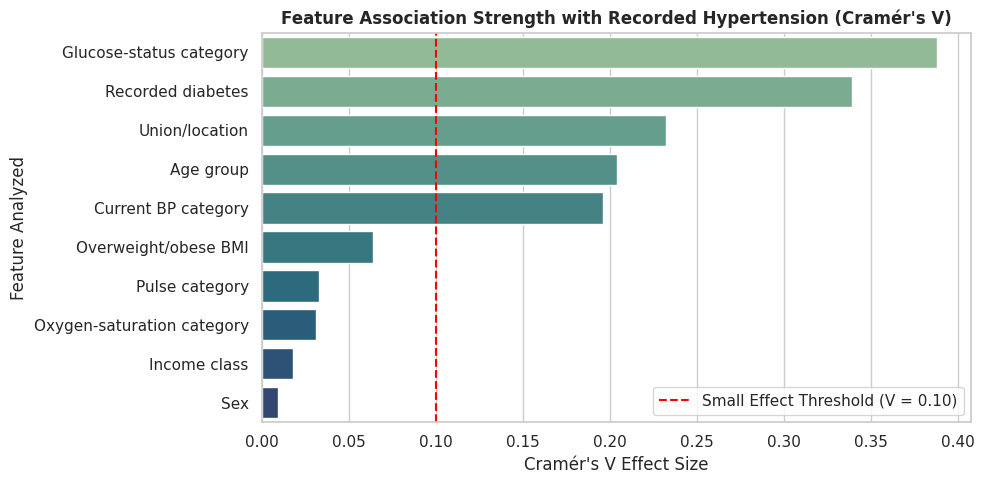

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results.sort_values(by='Cramers_V', ascending=False), x='Cramers_V', y='Feature', palette='crest')
plt.axvline(x=0.10, color='red', linestyle='--', label='Small Effect Threshold (V = 0.10)')
plt.title("Feature Association Strength with Recorded Hypertension (Cramér's V)", fontsize=12, fontweight='bold')
plt.xlabel("Cramér's V Effect Size")
plt.ylabel("Feature Analyzed")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 3. Key Findings & Data Limitations

1. **Strongest Usable Predictors:** Recorded diabetes ($V=0.339$), location/union ($V=0.232$), age group ($V=0.204$), and BP category ($V=0.196$)[cite: 8].
2. **Negligible Associations:** Pulse, income, BMI, and oxygen saturation are statistically significant ($p_{BH} < 0.05$) due to sample size but exhibit negligible effect sizes ($V < 0.07$)[cite: 8].
3. **Extreme Missingness:** Height/weight/BMI (96.2% missing), glucose (94.7% missing), oxygen saturation (85.5% missing), and MUAC (99.8% missing)[cite: 8].
4. **Recommendations:** Build a forward-looking multilevel logistic model for recorded hypertension using age, sex, diabetes, income, and location with household random intercepts[cite: 8]. Omit BP category and glucose labels to prevent target leakage[cite: 8].